# Arithmetic-Geometric Mean as a Dynamical System

The arithmetic-geometric mean (AGM) is a classical iterative process with deep links to elliptic integrals,
fast numerical algorithms, and mean inequalities.

For positive numbers $(a_0,g_0)$:
$$
a_{k+1}=\frac{a_k+g_k}{2},\qquad g_{k+1}=\sqrt{a_k g_k}.
$$
Both sequences converge to the same limit $\operatorname{AGM}(a_0,g_0)$.

We extend this pointwise on a 2D grid to visualize convergence and contraction.


## Environment

We work with matrix-valued fields and iterate AGM pointwise.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

plt.rcParams["figure.dpi"] = 120


## Initial pair of fields

Define two positive maps $A_0(x,y)$ and $G_0(x,y)$ on the unit square.


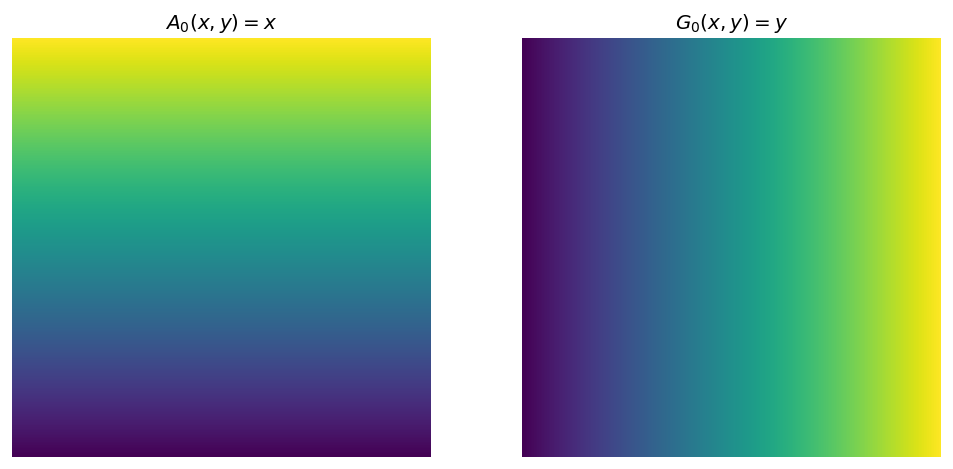

In [2]:
n = 420
t = np.linspace(1e-3, 1, n)
Y, X = np.meshgrid(t, t)
A0 = X
G0 = Y

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.8), constrained_layout=True)
axes[0].imshow(A0, origin="lower", cmap="viridis")
axes[0].set_title(r"$A_0(x,y)=x$")
axes[1].imshow(G0, origin="lower", cmap="viridis")
axes[1].set_title(r"$G_0(x,y)=y$")
for ax in axes:
    ax.axis("off")
plt.show()


## AGM iteration map

The transformation is monotone and squeezes the gap $A_k-G_k$.


In [3]:
def agm_iter(A, G):
    return (A + G) / 2, np.sqrt(np.maximum(A * G, 0))

def agm_field(A0, G0, n_iter):
    A, G = A0.copy(), G0.copy()
    history = [(A.copy(), G.copy())]
    for _ in range(n_iter):
        A, G = agm_iter(A, G)
        history.append((A.copy(), G.copy()))
    return history

hist = agm_field(A0, G0, 30)


## Interactive convergence

We display $A_k$, $G_k$, and discrepancy
$$
\Delta_k = |A_k-G_k|.
$$


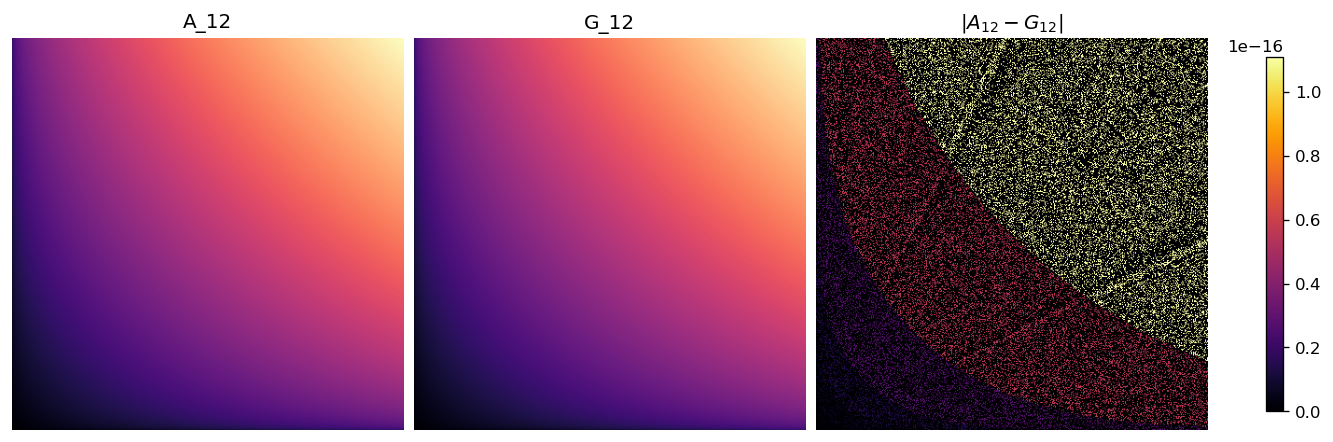

In [4]:
def show_agm(k=0):
    A, G = hist[k]
    D = np.abs(A - G)
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), constrained_layout=True)
    im0 = axes[0].imshow(A, origin="lower", cmap="magma")
    axes[0].set_title(f"A_{k}")
    im1 = axes[1].imshow(G, origin="lower", cmap="magma")
    axes[1].set_title(f"G_{k}")
    im2 = axes[2].imshow(D, origin="lower", cmap="inferno")
    axes[2].set_title(rf"$|A_{{{k}}}-G_{{{k}}}|$")
    for ax in axes:
        ax.axis("off")
    fig.colorbar(im2, ax=axes[2], shrink=0.8)
    plt.show()

# Static call for headless execution (keeps a representative convergence snapshot).
show_agm(k=min(12, len(hist)-1));


## Contraction diagnostics

Track mean and max discrepancy across iterations.


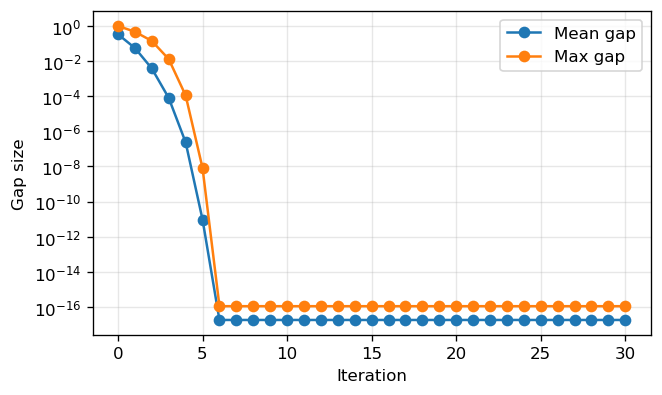

In [5]:
mean_gap = []
max_gap = []
for A, G in hist:
    D = np.abs(A - G)
    mean_gap.append(D.mean())
    max_gap.append(D.max())

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(mean_gap, "o-", label="Mean gap")
ax.plot(max_gap, "o-", label="Max gap")
ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("Gap size")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## Bibliographical resources

- Jonathan Borwein and Peter Borwein, *Pi and the AGM*.
- Carl Friedrich Gauss, original memoirs on arithmetic-geometric mean.
- Richard Brent and Paul Zimmermann, *Modern Computer Arithmetic* (AGM-based fast algorithms).
